In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/retail_features.csv')

In [ ]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  int64  
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
 8   Revenue      397884 non-null  float64
 9   Year         397884 non-null  int64  
 10  Month        397884 non-null  int64  
 11  MonthName    397884 non-null  object 
 12  Day          397884 non-null  int64  
 13  Hour         397884 non-null  int64  
 14  Weekday      397884 non-null  object 
dtypes: float64(3), int64(6), object(6)
memory usage: 45.5+ MB


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0
Year,0


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [ ]:
rfm.columns = ['Recency','Frequency','Monetary']

In [ ]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


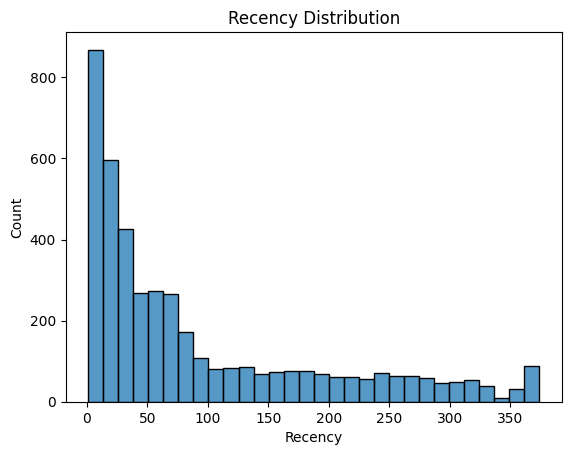

In [ ]:
sns.histplot(rfm['Recency'], bins=30)
plt.title('Recency Distribution')
plt.show()

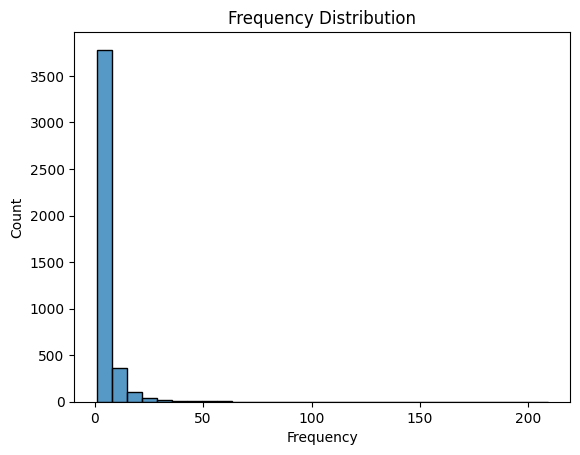

In [ ]:
sns.histplot(rfm['Frequency'], bins=30)
plt.title('Frequency Distribution')
plt.show()

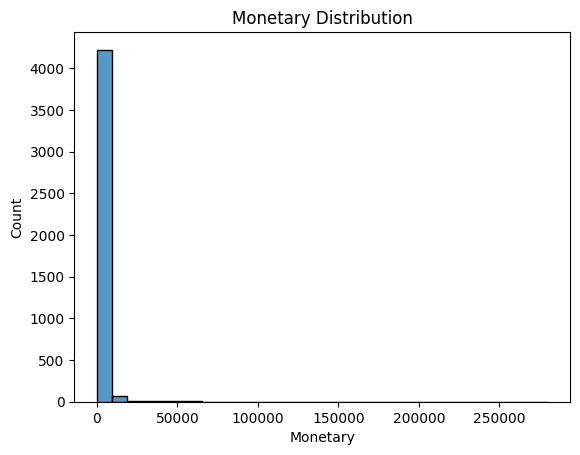

In [ ]:
sns.histplot(rfm['Monetary'], bins=30)
plt.title('Monetary Distribution')
plt.show()

In [ ]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

In [ ]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [ ]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r == 5 and f >= 4 and m >= 4: return 'Champions'
    elif r >= 3 and f >= 4 and m >= 3: return 'Loyal Customers'
    elif r >= 4 and f >= 2 and m >= 2: return 'Potential Loyalists'
    elif r == 5 and f == 1: return 'New Customers'
    elif r == 4 and f == 1: return 'Promising'
    elif r == 3 and f == 3: return 'Needing Attention'
    elif r == 3 and f <= 2: return 'About To Sleep'
    elif r <= 2 and f >= 4 and m >= 4: return 'Cannot Lose Them'
    elif r <= 2 and f >= 3: return 'At Risk'
    elif r <= 2 and f <= 2: return 'Hibernating'
    else: return 'Others'

In [ ]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
Hibernating,1065
Loyal Customers,852
Champions,557
At Risk,477
Potential Loyalists,429
About To Sleep,351
Needing Attention,186
Cannot Lose Them,166
Others,114


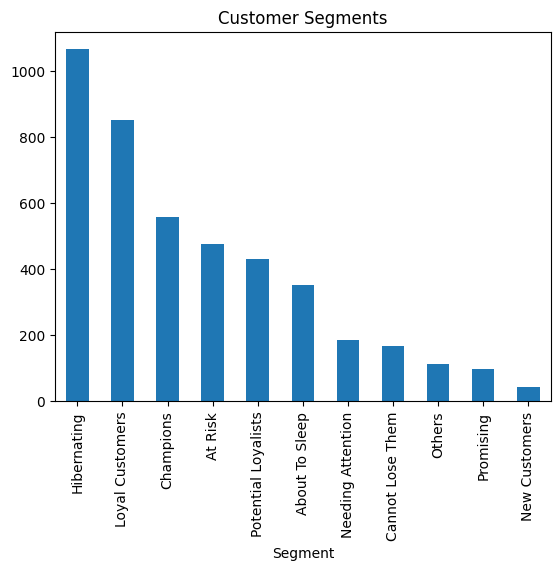

In [ ]:
rfm['Segment'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Segments')
plt.show()

In [ ]:
rfm.reset_index(inplace=True)
rfm.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/rfm_customer_segments.csv',
    index=False
)

Customers were segmented using a rule-based RFM framework based on their Recency, Frequency, and Monetary scores. The segmentation thresholds were defined to categorize customers into actionable groups such as Champions, Loyal Customers, At Risk, and Hibernating customers.

| Segment             | Meaning                                          |
| ------------------- | ------------------------------------------------ |
| Champions           | Best customers                                   |
| Loyal Customers     | Frequent and valuable                            |
| Potential Loyalists | Good potential to become loyal                   |
| New Customers       | Very recent customers                            |
| Promising           | Recently acquired customers                      |
| Needing Attention   | Starting to become less engaged                  |
| About To Sleep      | Engagement is declining                          |
| Cannot Lose Them    | Previously valuable customers who may be leaving |
| At Risk             | Customers likely to churn                        |
| Hibernating         | Inactive, low-engagement customers               |

Hibernating customers are the largest segment (24.6%), indicating a significant customer reactivation opportunity.

Loyal Customers and Champions form a strong high-value base, together accounting for 32.5% of customers.

At Risk and Cannot Lose Them customers need immediate attention to prevent churn and retain valuable customers.

Potential Loyalists represent a growth opportunity and can be converted into Loyal Customers through targeted engagement.

The small New Customers segment (1%) suggests potential scope for improving customer acquisition and early-stage retention.


The segmentation shows a dual challenge for the business: while it has a strong base of Loyal Customers and Champions, a significant proportion of customers are Hibernating or At Risk. Therefore, the business should focus on both retaining its high-value customers and implementing targeted reactivation strategies to reduce customer inactivity and potential churn.